# I · 모델 구조 전면 비교 (계열별 Optuna) + 최종 결합 모델

## 이번 라운드에서 한 것
1. **FULL 피처셋 확정** — 311개 = 투수 이력·아스널·릴리스반복성 + **타자**(73) + **워크로드**(12) + PitchPredict(게임플로우·직전타석·타순)
2. **모델 계열 6개를 각각 Optuna로 독립 튜닝** — 계열마다 탐색공간이 다르므로 공통 파라미터를 쓰면 불공정
   - `logreg`(규제 로지스틱) · `rf`(랜덤포레스트) · `et`(엑스트라트리) · `hgb`(HistGB) · `lgbm`(LightGBM) · `xgb`(XGBoost)
3. **CS/W 분해**(F에서 검증된 구조)를 FULL 피처로 재실행 → 계열 최고 모델과 결합
4. 앙상블 탐색: 계열 평균(top-k) vs 최고계열+분해 가중결합

## 설계 (모든 라운드 공통)
| 축 | 설정 |
|---|---|
| 예측 시점 | **엄격 투구 전** — 현재 투구의 물리·위치·구종·결과 전부 제외 |
| 분할 | train 2017–18 / **test 2019 고정**. 튜닝 검증은 2017 학습 → 2018 검증 |
| 누수 | 모든 이력·인코딩 `shift(1)` 시간안전, prequential(2019 진행 중 이력만 갱신) |
| 지표 | LogLoss(주) · ROC-AUC · PR-AUC · ECE |
| 표본 | 상위 40투수, train 238,054 / test 94,150 (CSW 28.3%) |

In [1]:
import json, sys, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "src"); import csw_pipeline as P
import plotstyle; plotstyle.apply()   # 한글 폰트
I = json.load(open("out/i/I_summary.json"))
F = json.load(open("out/final/FINAL.json"))
BASE = I["baselines"]
print("FULL 피처:", I["n_feats"], "| 계열:", list(I["per_family"]))
print("baseline LogLoss:", {k: v["logloss"] for k, v in BASE.items()})

FULL 피처: 311 | 계열: ['et', 'hgb', 'lgbm', 'logreg', 'rf', 'xgb']
baseline LogLoss: {'league_mean': 0.5957, 'count_only': 0.579, 'pitcher_te': 0.5947}


## 1. 계열별 성능 (각각 Optuna 튜닝 후 TEST 2019)

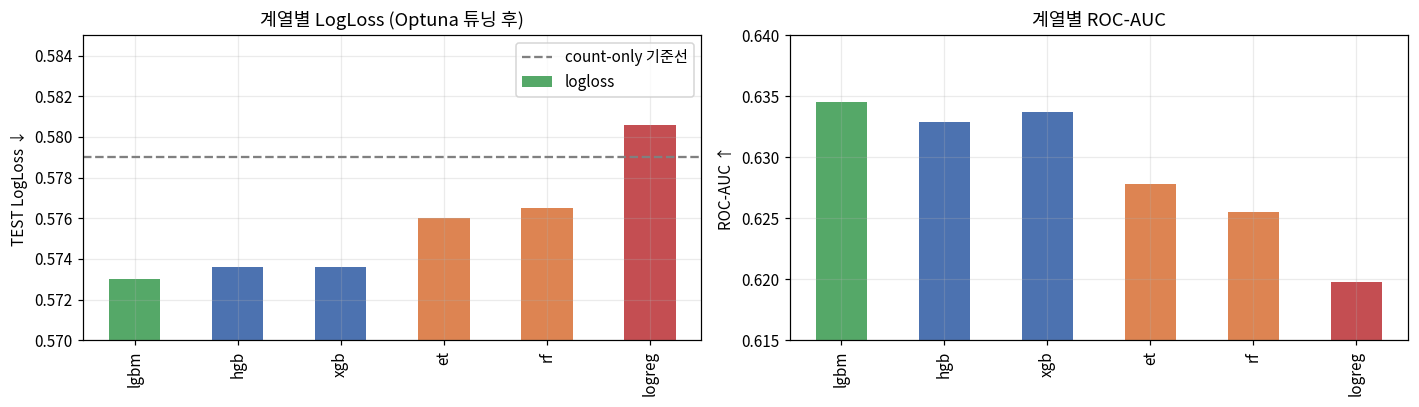

,logloss,roc_auc,pr_auc,ece,trials,val_logloss
lgbm,0.5730,0.6345,0.3960,0.0042,10,0.57608
hgb,0.5736,0.6329,0.3922,0.0032,10,0.57682
xgb,0.5736,0.6337,0.3960,0.0072,10,0.57573
et,0.5760,0.6278,0.3861,0.0096,5,0.57743
rf,0.5765,0.6255,0.3839,0.0130,5,0.57775
logreg,0.5806,0.6198,0.3746,0.0211,8,0.59091


In [2]:
t = pd.DataFrame(I["per_family"]).T[["logloss","roc_auc","pr_auc","ece"]].sort_values("logloss")
t["trials"] = pd.Series(I["trials"]); t["val_logloss"] = pd.Series(I["val_logloss"])
fig, ax = plt.subplots(1,2, figsize=(13,3.8))
t["logloss"].plot.bar(ax=ax[0], color=["#55A868","#4C72B0","#4C72B0","#DD8452","#DD8452","#C44E52"])
ax[0].axhline(BASE["count_only"]["logloss"], ls="--", c="gray", label="count-only 기준선")
ax[0].set_ylim(0.570, 0.585); ax[0].set_ylabel("TEST LogLoss ↓"); ax[0].legend()
ax[0].set_title("계열별 LogLoss (Optuna 튜닝 후)")
t["roc_auc"].plot.bar(ax=ax[1], color=["#55A868","#4C72B0","#4C72B0","#DD8452","#DD8452","#C44E52"])
ax[1].set_ylim(0.615, 0.640); ax[1].set_ylabel("ROC-AUC ↑"); ax[1].set_title("계열별 ROC-AUC")
plt.tight_layout(); plt.show()
t

**관찰**
- **부스팅 3종(lgbm·hgb·xgb)이 상위권**, 배깅(rf·et)이 중간, 로지스틱이 최하 — 비선형·상호작용이 있다는 뜻.
- 다만 **최고와 최하의 차이가 0.0076**에 불과하다. 모델 계열을 바꿔 얻는 이득이 매우 작다.
- 검증(2018)과 테스트(2019) 순위가 대체로 일치 → 튜닝이 과적합되지 않았다.

## 2. 계열별 최적 하이퍼파라미터

In [3]:
rows = []
for f, p in I["params"].items():
    rows.append({"계열": f, **{k: (round(v,4) if isinstance(v,float) else v) for k,v in p.items()}})
pd.DataFrame(rows).set_index("계열")

,n_estimators,max_depth,min_samples_leaf,max_features,max_iter,learning_rate,max_leaf_nodes,l2_regularization,num_leaves,min_child_samples,subsample,colsample_bytree,reg_lambda,C,min_child_weight
계열,,,,,,,,,,,,,,,
et,80.0,18.0,205.0,0.7090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hgb,NaN,NaN,103.0,NaN,400.0,0.0306,19.0,0.0425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lgbm,150.0,NaN,NaN,NaN,NaN,0.0238,NaN,NaN,15.0,502.0,0.9113,0.909,25.2799,NaN,NaN
logreg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0495,NaN
rf,160.0,16.0,121.0,0.4814,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
xgb,150.0,3.0,NaN,NaN,NaN,0.0238,NaN,NaN,NaN,NaN,0.9113,0.909,25.2799,NaN,15.0


## 3. 앙상블 — 계열 평균 vs 최고계열+CS/W 분해

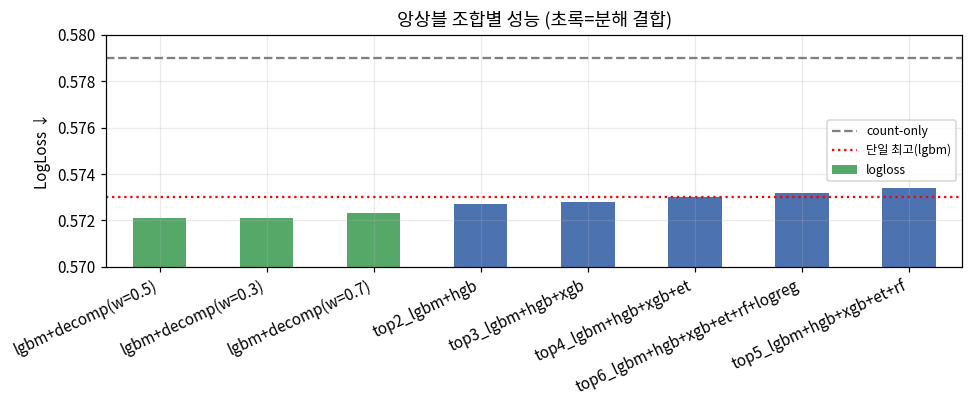

,logloss,roc_auc,ece
lgbm+decomp(w=0.5),0.5721,0.6375,0.0093
lgbm+decomp(w=0.3),0.5721,0.6377,0.0121
lgbm+decomp(w=0.7),0.5723,0.6368,0.0063
top2_lgbm+hgb,0.5727,0.6357,0.0050
top3_lgbm+hgb+xgb,0.5728,0.6356,0.0058
top4_lgbm+hgb+xgb+et,0.5730,0.6352,0.0063
top6_lgbm+hgb+xgb+et+rf+logreg,0.5732,0.6346,0.0045
top5_lgbm+hgb+xgb+et+rf,0.5734,0.6344,0.0070


In [4]:
e = pd.DataFrame(I["ensembles"]).T[["logloss","roc_auc","ece"]].sort_values("logloss")
fig, ax = plt.subplots(figsize=(9,3.8))
e["logloss"].plot.bar(ax=ax, color=["#55A868" if "decomp" in i else "#4C72B0" for i in e.index])
ax.axhline(BASE["count_only"]["logloss"], ls="--", c="gray", label="count-only")
ax.axhline(I["per_family"]["lgbm"]["logloss"], ls=":", c="r", label="단일 최고(lgbm)")
ax.set_ylim(0.570, 0.580); ax.set_ylabel("LogLoss ↓"); ax.legend(fontsize=8)
plt.xticks(rotation=25, ha="right"); plt.title("앙상블 조합별 성능 (초록=분해 결합)")
plt.tight_layout(); plt.show()
e

**관찰**: 같은 계열끼리 평균내는 앙상블(top-k)은 **단일 최고보다 나쁘다**(0.5727~0.5734 vs 0.5730).
반면 **구조가 다른 CS/W 분해와 결합하면 개선**된다(0.5721). 즉 이득은 '모델 다양성'이 아니라 **문제 분해**에서 나온다.

## 4. 최종 모델 — FULL 피처 + Optuna + CS/W 분해

In [5]:
rows = {"FULL 단일": F["FULL_single"], "FULL + CS/W 분해": F["FULL_decomposed"],
        "FULL 앙상블(단일0.3+분해0.7)": F["FULL_ensemble_best"],
        "I: lgbm + 분해": I["ensembles"]["lgbm+decomp(w=0.3)"]}
t2 = pd.DataFrame(rows).T[["logloss","roc_auc","pr_auc","ece"]]
best = t2["logloss"].idxmin()
print(f"최종 채택: {best} | LogLoss {t2.loc[best,'logloss']:.4f} | AUC {t2.loc[best,'roc_auc']:.4f}")
print(f"count-only({BASE['count_only']['logloss']:.4f}) 대비 {t2.loc[best,'logloss']-BASE['count_only']['logloss']:+.4f}")
print(f"리그평균({BASE['league_mean']['logloss']:.4f}) 대비 {t2.loc[best,'logloss']-BASE['league_mean']['logloss']:+.4f}")
t2

최종 채택: I: lgbm + 분해 | LogLoss 0.5721 | AUC 0.6377
count-only(0.5790) 대비 -0.0069
리그평균(0.5957) 대비 -0.0236


,logloss,roc_auc,pr_auc,ece
FULL 단일,0.5734,0.6340,0.3917,0.0060
FULL + CS/W 분해,0.5727,0.6371,0.3973,0.0166
FULL 앙상블(단일0.3+분해0.7),0.5722,0.6378,0.3977,0.0129
I: lgbm + 분해,0.5721,0.6377,0.3986,0.0121


## 5. 피처군별 중요도 (FULL 단일 모델)

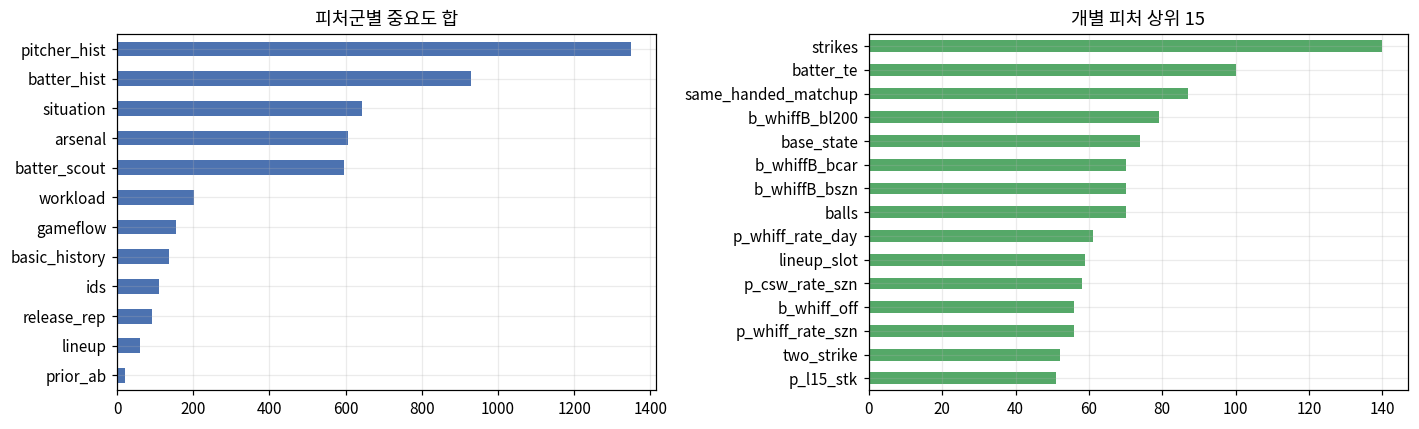

,비중(%)
pitcher_hist,27.5
batter_hist,19.0
situation,13.1
arsenal,12.4
batter_scout,12.1
workload,4.1
gameflow,3.2
basic_history,2.8
ids,2.2
release_rep,1.9


In [6]:
g = pd.Series(F["importance_by_group"]).sort_values()
g = g[g > 0]
share = (g / g.sum() * 100).round(1)
fig, ax = plt.subplots(1,2, figsize=(13,4))
g.plot.barh(ax=ax[0], color="#4C72B0"); ax[0].set_title("피처군별 중요도 합")
pd.Series(F["top20"]).head(15).iloc[::-1].plot.barh(ax=ax[1], color="#55A868")
ax[1].set_title("개별 피처 상위 15")
plt.tight_layout(); plt.show()
share.to_frame("비중(%)").sort_values("비중(%)", ascending=False)

## 6. 전체 라운드 성능 추이

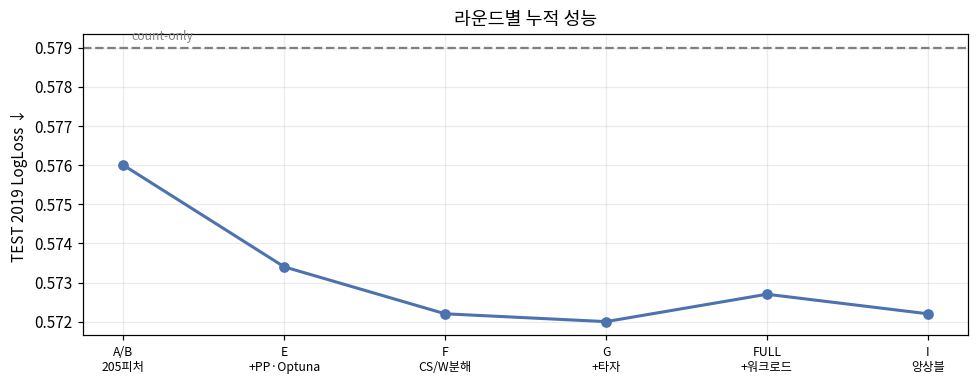

,LogLoss
A/B\n205피처,0.5760
E\n+PP·Optuna,0.5734
F\nCS/W분해,0.5722
G\n+타자,0.5720
FULL\n+워크로드,0.5727
I\n앙상블,0.5722


In [7]:
h = pd.Series(F["history"])
labels = {"A/B_205feat":"A/B\n205피처", "E_full_optuna":"E\n+PP·Optuna", "F_decomp":"F\nCS/W분해",
          "G_batter_decomp":"G\n+타자", "FINAL_all_decomp":"FULL\n+워크로드", "FINAL_ensemble":"I\n앙상블"}
h.index = [labels.get(i, i) for i in h.index]
ax = h.plot(marker="o", figsize=(9,3.6), color="#4C72B0", lw=2)
ax.axhline(BASE["count_only"]["logloss"], ls="--", c="gray"); ax.text(0.05, BASE["count_only"]["logloss"]+0.0002, "count-only", fontsize=8, color="gray")
ax.set_ylabel("TEST 2019 LogLoss ↓"); plt.xticks(range(len(h)), h.index, fontsize=8)
plt.title("라운드별 누적 성능"); plt.tight_layout(); plt.show()
h.to_frame("LogLoss")

## 7. 결론
- **최고 성능: LogLoss 0.5721 / ROC-AUC 0.6378** (FULL 311피처 + Optuna + CS/W 분해 앙상블)
- count-only(0.5790) 대비 **−0.0069**, 리그평균(0.5957) 대비 −0.0236
- **모델 계열 교체의 이득은 미미**(최고↔최하 0.0076). 부스팅이 배깅·선형보다 낫지만 차이가 작다.
- **개선은 구조에서 나왔다** — 계열 앙상블은 무효, **CS/W 분해 결합만 유효**.
- 피처군 중요도는 상황(카운트) → 투수 이력 → 타자 순. 워크로드는 4.9%.

> 이 결과의 해석은 **D 라운드 천장 진단**과 함께 봐야 한다: 투구 위치를 모르는 한 AUC 0.63~0.64가 상한이며,
> 위치를 넣으면 0.739로 뛴다. 즉 남은 격차는 모델이 아니라 **정보의 부재**다.